# 01 — Exploring the running data

This notebook looks at the two files built by `python -m running_coach.data.prepare`:

- **`sample.parquet`**: every clean run of 1,000 random athletes from 2019 (this is what the app uses).
- **`reference.parquet`**: percentiles by runner level, calculated from **all** 2019 athletes.

Data: *A public dataset on long-distance running training in 2019 and 2020*
(Afonseca, Watanabe & Duarte, BMClab/UFABC, PeerJ 2022), licence CC BY 4.0.

To run it: `python -m running_coach.data.download`, then `python -m running_coach.data.prepare`, then run all cells.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from running_coach.data.loaders import load_reference, load_sample
from running_coach.data.prepare import LEVEL_LABELS, summarize_athletes

sample = load_sample()  # adds the pace column (not stored in the file)
reference = load_reference()

## 1. Size of the sample

In [2]:
print(f"Runs:      {len(sample):,}")
print(f"Athletes:  {sample['athlete'].nunique():,}")
print(f"Dates:     {sample['datetime'].min():%Y-%m-%d} to {sample['datetime'].max():%Y-%m-%d}")
print(f"Runs per athlete (median): {sample.groupby('athlete').size().median():.0f}")
print()
print("Athletes by gender:")
print(sample.groupby("gender")["athlete"].nunique())

Runs:      133,562
Athletes:  1,000
Dates:     2019-01-01 to 2019-12-31
Runs per athlete (median): 125

Athletes by gender:
gender
F    249
M    751
Name: athlete, dtype: int64


In [3]:
sample.head()

,datetime,athlete,distance,duration,gender,pace
0,2019-01-05,13,11.28,59.516667,M,5.276300
1,2019-01-06,13,9.98,53.100000,M,5.320641
2,2019-01-12,13,16.09,85.000000,M,5.282784
3,2019-01-19,13,4.93,21.916667,M,4.445571
4,2019-01-20,13,16.10,84.000000,M,5.217391


In [4]:
sample[["distance", "duration", "pace"]].describe().round(2)

,distance,duration,pace
count,133562.00,133562.00,133562.00
mean,11.92,64.97,5.52
std,7.64,47.48,1.19
min,0.50,1.57,2.53
25%,6.88,38.25,4.81
50%,10.01,53.77,5.29
75%,14.62,76.00,5.91
max,99.87,1211.00,15.00


## 2. Distance per run

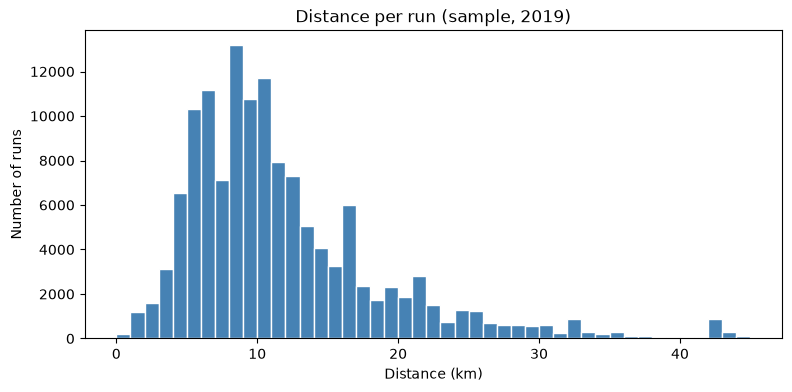

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample["distance"], bins=range(0, 46), color="steelblue", edgecolor="white")
ax.set_title("Distance per run (sample, 2019)")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Number of runs")
plt.show()

**What it shows:** most runs are between 5 and 15 km, and the median run is 10 km.
The chart has spikes at "round" distances: 16 km (10 miles), 21 km (half marathon) and 42 km (marathon).
Runners like round numbers, and many athletes in this dataset count in miles.
Long runs over 25 km are rare but real: these athletes train for marathons.

## 3. Pace per run

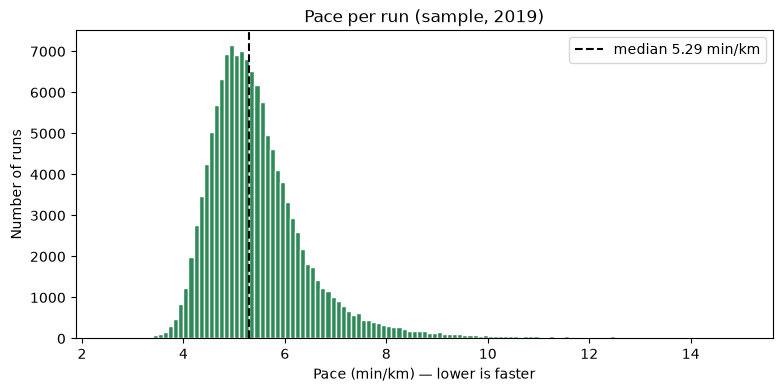

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample["pace"], bins=[2.5 + 0.1 * i for i in range(126)], color="seagreen", edgecolor="white")
ax.axvline(sample["pace"].median(), color="black", linestyle="--", label=f"median {sample['pace'].median():.2f} min/km")
ax.set_title("Pace per run (sample, 2019)")
ax.set_xlabel("Pace (min/km) — lower is faster")
ax.set_ylabel("Number of runs")
ax.legend()
plt.show()

**What it shows:** most runs are between 4 and 7 min/km, with a median of about 5:17 min/km.
The right tail is longer than the left one: running much slower is easy (easy runs, hills, walking breaks),
but running much faster than 4 min/km is hard. Our cleaning limits (2.5 and 15 min/km) sit far outside
the main shape, so they only remove clear errors.

## 4. Runs per week

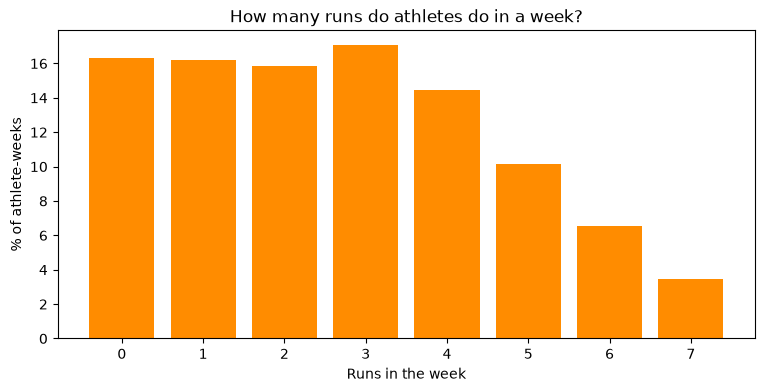

Weeks with no run: 16.3%


In [7]:
# Same weekly logic as prepare.py: Monday-Sunday weeks, from each athlete's first to last run.
weekly_runs = (
    sample.set_index("datetime")
    .groupby("athlete")["distance"]
    .resample("W-SUN")
    .count()
)
share = weekly_runs.value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(share.index, share.values, color="darkorange")
ax.set_title("How many runs do athletes do in a week?")
ax.set_xlabel("Runs in the week")
ax.set_ylabel("% of athlete-weeks")
ax.set_xticks(share.index)
plt.show()

print(f"Weeks with no run: {share.get(0, 0):.1f}%")

**What it shows:** each bar is one "athlete-week" (one athlete, one week). Weeks with 0, 1, 2 or 3 runs are
about equally common; 4 or more runs per week is less common, and running every day (7) is rare.
About 1 in 6 weeks has **no run at all** (rest, illness, holidays). This is normal, so the coach agent
should not treat one empty week as a problem.

## 5. Athletes per level

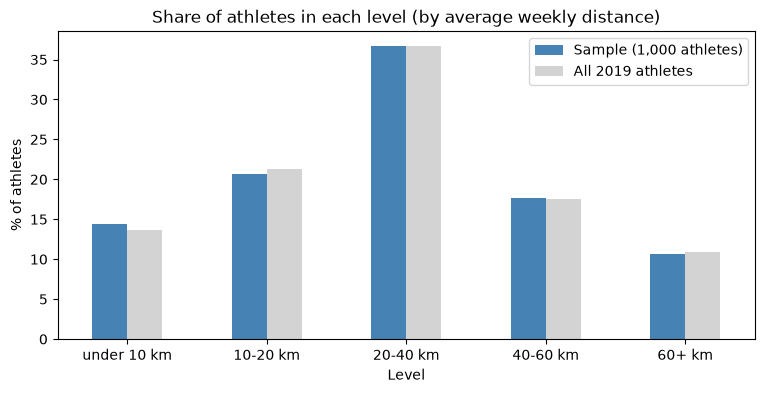

,"Sample (1,000 athletes)",All 2019 athletes
level,,
under 10 km,14.4,13.6
10-20 km,20.7,21.3
20-40 km,36.7,36.7
40-60 km,17.6,17.5
60+ km,10.6,10.9


In [8]:
athletes = summarize_athletes(sample)
sample_share = athletes["level"].value_counts(normalize=True).reindex(LEVEL_LABELS) * 100
all_share = reference.set_index("level")["n_athletes"].reindex(LEVEL_LABELS)
all_share = all_share / all_share.sum() * 100

levels = pd.DataFrame({"Sample (1,000 athletes)": sample_share, "All 2019 athletes": all_share})
ax = levels.plot.bar(figsize=(9, 4), rot=0, color=["steelblue", "lightgray"])
ax.set_title("Share of athletes in each level (by average weekly distance)")
ax.set_xlabel("Level")
ax.set_ylabel("% of athletes")
plt.show()

levels.round(1)

**What it shows:** the share of athletes in each level, in our sample (blue) and in all 2019 athletes (grey).
The bars are almost the same height (less than 1 percentage point apart), so the random sample
**represents** the full dataset well. The biggest group is 20-40 km per week.

## 6. The reference table

In [9]:
reference

,level,n_athletes,weekly_km_p25,weekly_km_p50,weekly_km_p75,pace_p25,pace_p50,pace_p75,runs_per_week_p25,runs_per_week_p50,runs_per_week_p75
0,under 10 km,4741,3.97,6.11,8.17,5.45,5.99,6.73,0.53,0.75,1.00
1,10-20 km,7388,12.64,15.11,17.58,5.33,5.81,6.43,1.27,1.57,1.88
2,20-40 km,12768,24.17,28.66,33.70,5.13,5.57,6.11,2.21,2.62,3.06
3,40-60 km,6085,43.57,47.88,53.21,4.87,5.25,5.73,3.43,3.87,4.32
4,60+ km,3778,65.08,72.49,84.58,4.61,4.93,5.34,4.65,5.15,5.69


**How to read it:** each row is one level. `_p25`, `_p50` and `_p75` are the 25th, 50th (median) and 75th
percentiles. For example, in the 20-40 km level, half of the runners run less than `weekly_km_p50` km per week.
For pace, a **lower** number is **faster**, so `pace_p25` is the pace of the faster runners in the level.

The more a level runs, the faster its pace and the more runs per week it has. This is the table the agents
will use to compare a user with runners at their own level.